In [4]:
import mysql.connector
import pandas as pd

In [5]:
conn = mysql.connector.connect(host = 'localhost', user = 'root', password = '', database = 'world')

In [6]:
df = pd.read_sql_query("SELECT * FROM country", conn)
df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_492\1512770336.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("SELECT * FROM country", conn)


,Code,Name,Continent,Region,SurfaceArea,IndepYear,Population,LifeExpectancy,GNP,GNPOld,LocalName,GovernmentForm,HeadOfState,Capital,Code2
0,ABW,Aruba,North America,Caribbean,193.0,NaN,103000,78.4,828.0,793.0,Aruba,Nonmetropolitan Territory of The Netherlands,Beatrix,129.0,AW
1,AFG,Afghanistan,Asia,Southern and Central Asia,652090.0,1919.0,22720000,45.9,5976.0,NaN,Afganistan/Afqanestan,Islamic Emirate,Mohammad Omar,1.0,AF
2,AGO,Angola,Africa,Central Africa,1246700.0,1975.0,12878000,38.3,6648.0,7984.0,Angola,Republic,José Eduardo dos Santos,56.0,AO
3,AIA,Anguilla,North America,Caribbean,96.0,NaN,8000,76.1,63.2,NaN,Anguilla,Dependent Territory of the UK,Elisabeth II,62.0,AI
4,ALB,Albania,Europe,Southern Europe,28748.0,1912.0,3401200,71.6,3205.0,2500.0,Shqipëria,Republic,Rexhep Mejdani,34.0,AL


In [ ]:
#shapes of dataset
df.shape

(239, 15)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Code            239 non-null    str    
 1   Name            239 non-null    str    
 2   Continent       239 non-null    str    
 3   Region          239 non-null    str    
 4   SurfaceArea     239 non-null    float64
 5   IndepYear       192 non-null    float64
 6   Population      239 non-null    int64  
 7   LifeExpectancy  222 non-null    float64
 8   GNP             239 non-null    float64
 9   GNPOld          178 non-null    float64
 10  LocalName       239 non-null    str    
 11  GovernmentForm  239 non-null    str    
 12  HeadOfState     238 non-null    str    
 13  Capital         232 non-null    float64
 14  Code2           239 non-null    str    
dtypes: float64(6), int64(1), str(8)
memory usage: 28.1 KB


In [10]:
df.isnull().sum()

Code               0
Name               0
Continent          0
Region             0
SurfaceArea        0
IndepYear         47
Population         0
LifeExpectancy    17
GNP                0
GNPOld            61
LocalName          0
GovernmentForm     0
HeadOfState        1
Capital            7
Code2              0
dtype: int64

In [11]:

df['LifeExpectancy'].fillna(df['LifeExpectancy'].mean(), inplace=True)
df['GNPOld'].fillna(df['GNPOld'].mean(), inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_492\1831431077.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['LifeExpectancy'].fillna(df['LifeExpectancy'].mean(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_492\1831431077.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chaine

0         793.000000
1      165534.314607
2        7984.000000
3      165534.314607
4        2500.000000
           ...      
234      5729.000000
235    165534.314607
236    129092.000000
237      3922.000000
238      8670.000000
Name: GNPOld, Length: 239, dtype: float64

In [ ]:
df['HeadOfState'].fillna("Unknown", inplace=True)   # string column

df['Capital'].fillna(df['Capital'].median(), inplace=True)   # numeric column

C:\Users\HP\AppData\Local\Temp\ipykernel_492\4077023414.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['HeadOfState'].fillna("Unknown", inplace=True)   # string column ✔
C:\Users\HP\AppData\Local\Temp\ipykernel_492\4077023414.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained

0       129.0
1         1.0
2        56.0
3        62.0
4        34.0
        ...  
234    1780.0
235    1792.0
236     716.0
237    3162.0
238    4068.0
Name: Capital, Length: 239, dtype: float64

## SQL Analysis

In [14]:
pd.read_sql_query("""SELECT Name, population FROM country ORDER BY Population DESC LIMIT 10 """, conn)

C:\Users\HP\AppData\Local\Temp\ipykernel_492\1954239205.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query("""SELECT Name, population FROM country ORDER BY Population DESC LIMIT 10 """, conn)


,Name,population
0,China,1277558000
1,India,1013662000
2,United States,278357000
3,Indonesia,212107000
4,Brazil,170115000
5,Pakistan,156483000
6,Russian Federation,146934000
7,Bangladesh,129155000
8,Japan,126714000
9,Nigeria,111506000


In [15]:
pd.read_sql_query("""SELECT Continent, AVG(LifeExpectancy) as avg_life FROM country GROUP BY Continent""",conn )

C:\Users\HP\AppData\Local\Temp\ipykernel_492\567431541.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query("""SELECT Continent, AVG(LifeExpectancy) as avg_life FROM country GROUP BY Continent""",conn )


,Continent,avg_life
0,Asia,67.44118
1,Europe,75.14773
2,North America,72.99189
3,Africa,52.57193
4,Oceania,69.71500
5,Antarctica,NaN
6,South America,70.94615


In [16]:
pd.read_sql_query(""" SELECT Language, COUNT(*) as Count FROM countrylanguage GROUP BY Language ORDER BY count DESC LIMIT 10""",conn  )

C:\Users\HP\AppData\Local\Temp\ipykernel_492\2563920854.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query(""" SELECT Language, COUNT(*) as Count FROM countrylanguage GROUP BY Language ORDER BY count DESC LIMIT 10""",conn  )


,Language,Count
0,English,60
1,Arabic,33
2,Spanish,28
3,French,25
4,Chinese,19
5,German,19
6,Russian,17
7,Italian,15
8,Creole English,14
9,Ukrainian,12


C:\Users\HP\AppData\Local\Temp\ipykernel_492\2466112830.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top10 = pd.read_sql_query(""" SELECT Name, Population FROM Country ORDER BY Population DESC LIMIT 10""",conn)


<Figure size 800x500 with 0 Axes>

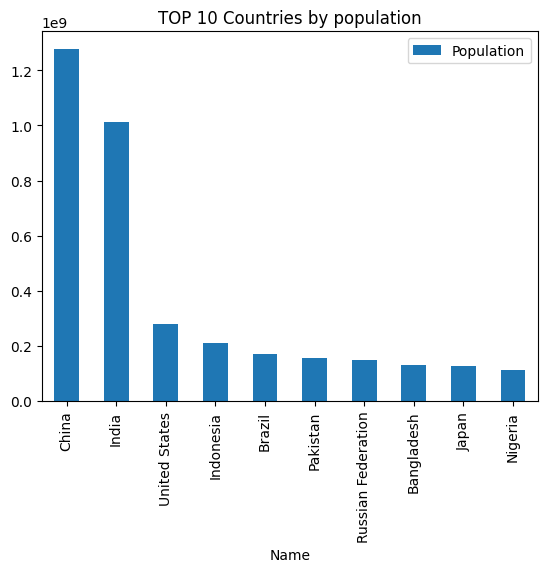

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
top10 = pd.read_sql_query(""" SELECT Name, Population FROM Country ORDER BY Population DESC LIMIT 10""",conn)
top10.plot(kind='bar', x='Name', y='Population')
plt.title("TOP 10 Countries by population")
plt.show()
